# Preparation molecular descriptors database

* Data preprocessing on Mordred and RDKit databases to then perform clustering on them
* Removal/Replacement of NAs (if any present)
* Variance threshold (set a min variance to not take into account $\Rightarrow$ little info if $\mathbb{V}[X_i] \rightarrow 0$ (with $X_i$ a molecular descriptor and $i = 1, ..., N$, $N$ the number of molecular descriptors))
* Correlation plot (heatmap with the package seaborn): remove highly correlated molecular descriptors (to avoid columns that resemble each other and therefore remove any noise in the db so that it is ready to run models on it, whether it is a stat/ML/DL model)


In [189]:
## libraries to import
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from cmcrameri import cm
import seaborn as sns
%matplotlib inline


In [190]:
sns.set(style = 'white', context = 'notebook', rc = {'figure.figsize':(14, 10)})


## I. Mordred database

#### I.1 - Import db:

In [191]:
data1 = pd.read_csv("../data/mordred_descriptors.csv", delimiter = ",")
data1.head(2)


,name,substance_type,CAS_nb,SMILES,detected,molecule,nAcid,nBase,SpAbs_A,SpMax_A,...,SRW09,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1
0,carbaryl,insecticide,63-25-2,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,<rdkit.Chem.rdchem.Mol object at 0x300994510>,0,0,19.544560,2.377815,...,0.0,9.496496,46.853672,201.078979,7.733807,362,21,74.0,85.0,4.694444
1,chlorpyrifos,insecticide,2921-88-2,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,<rdkit.Chem.rdchem.Mol object at 0x300995310>,0,0,20.971017,2.377461,...,0.0,9.677653,50.667067,348.926284,12.031941,612,26,86.0,97.0,8.256944


In [192]:
## get only mol. descr.:
mordred_md = data1.drop({"name", "substance_type", "CAS_nb", "SMILES", "detected", "molecule"}, axis = 1)


#### I.2 - NAs:

In [193]:
## check if any NAs before:
print(f"Number of NAs in Mordred database: \n {mordred_md.isna().sum()}")


Number of NAs in Mordred database: 
 nAcid       0
nBase       0
SpAbs_A     3
SpMax_A     3
SpDiam_A    3
           ..
WPath       0
WPol        0
Zagreb1     0
Zagreb2     0
mZagreb1    9
Length: 1504, dtype: int64


In [194]:
## check if inf values in data:
print(f"Number of infinite values in Mordred database: {np.isinf(mordred_md).sum().sum()}")


Number of infinite values in Mordred database: 0


In [195]:
## replace NAs w/ 0s:
mordred_md_nona = mordred_md.fillna(0)
mordred_md_nona.isna().sum().sum() ## sanity check


np.int64(0)

#### I.3 - Variance Threshold:

* Computes variance for each column;
* Set a threshold;
* If variance is lower than the threshold, don't select the column as the molecular descriptor contains little info and would not be useful for the analysis;
* Helps in reducing noise in database


In [196]:
selector = VarianceThreshold(threshold = 0.2)
var_reduced1 = selector.fit_transform(mordred_md_nona)


In [197]:
## transform to df (so it can be used more easily afterwards):
mordred_var = pd.DataFrame(var_reduced1, index = data1.name, columns = selector.get_feature_names_out())
mordred_var.head(2)


,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,LogEE_A,VE1_A,VE3_A,VR1_A,VR2_A,...,SRW09,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1
name,,,,,,,,,,,,,,,,,,,,,
carbaryl,0.0,19.544560,2.377815,4.755629,19.544560,3.627536,3.457764,1.646087,84.936994,5.662466,...,0.0,9.496496,46.853672,201.078979,7.733807,362.0,21.0,74.0,85.0,4.694444
chlorpyrifos,0.0,20.971017,2.377461,4.754921,20.971017,3.775189,3.759106,1.911968,97.874566,5.437476,...,0.0,9.677653,50.667067,348.926284,12.031941,612.0,26.0,86.0,97.0,8.256944


#### I.4 - Correlation:

* Remove variables highly correlated between them (+/-ly corr)
* AIM: avoid having 2 similar molecular descriptors


<Axes: >

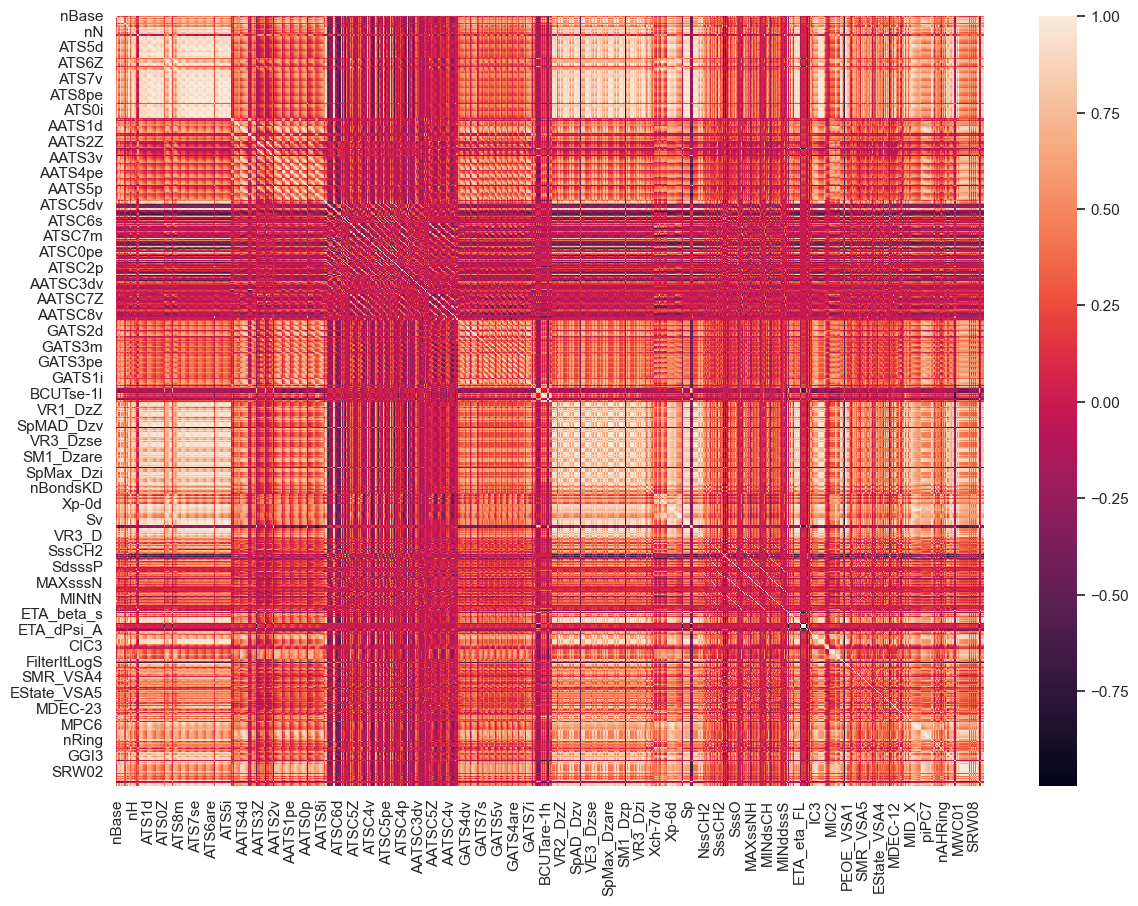

In [198]:
## correlation viz:
sns.heatmap(mordred_var.corr())


In [199]:
## correlation removal (2 vars highly corr => to remove):
corr_matrix1 = mordred_var.corr().abs() ## replace neg corr with their abs value
upper1 = corr_matrix1.where(np.triu(np.ones(corr_matrix1.shape), k = 1).astype(bool))

to_drop1 = [column for column in upper1.columns if any(upper1[column] > 0.9)] ## columns to remove due to high corr (say, 0.9)
mordred_nocorr = mordred_var.drop(columns = to_drop1)


<Axes: >

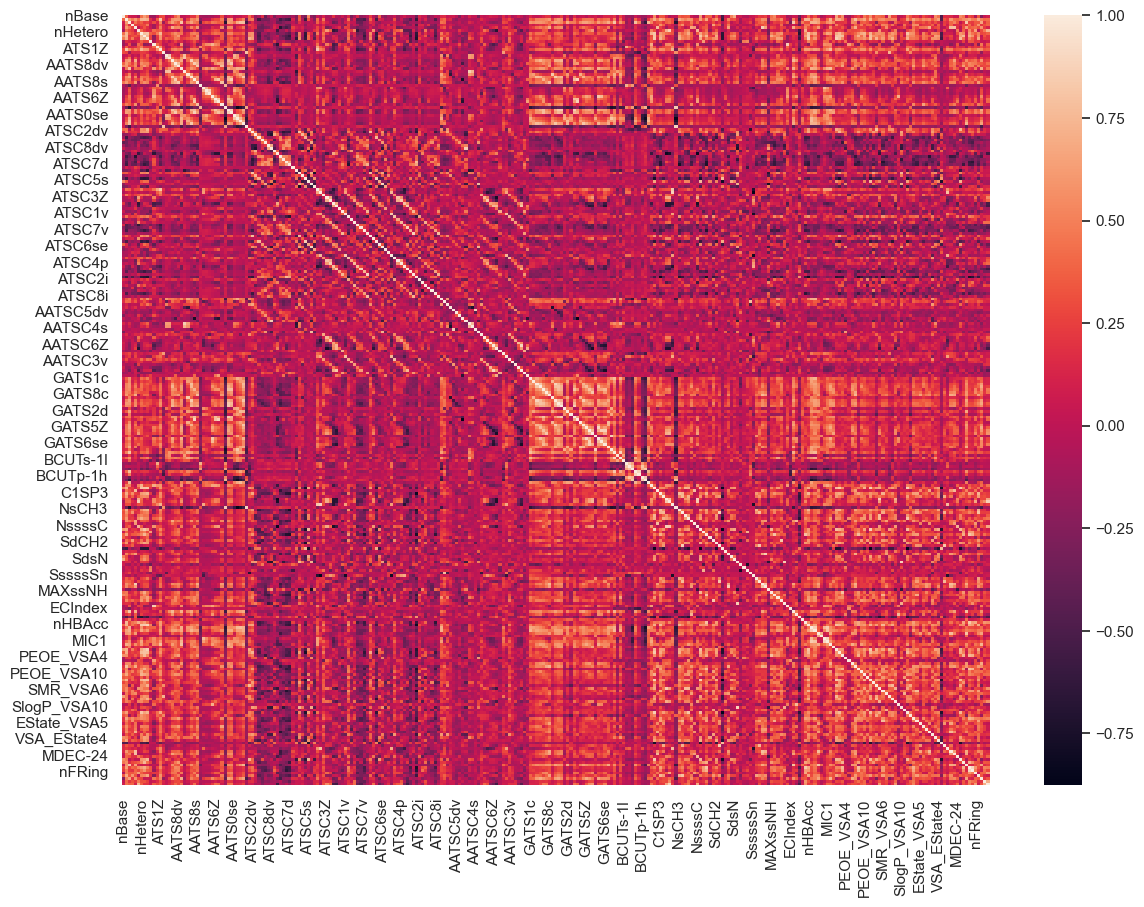

In [200]:
sns.heatmap(mordred_nocorr.corr())


In [201]:
print(f"Dimension of Mordred database after cleaning and filtering: {mordred_nocorr.shape}")


Dimension of Mordred database after cleaning and filtering: (67, 281)


#### I.5 - Save cleaned and filtered db in a .csv file:

In [202]:
## save cleaned & transformed db:
mordred_nocorr.to_csv("../data/mordred_clean.csv", index = False)


## II. RDKit database

#### II.1 - Import db:

In [203]:
data2 = pd.read_csv("../data/rdkit_descriptors.csv", delimiter = ",")
data2.head(2)


,name,substance_type,SMILES,detected,molecule,0,1,2,3,4,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,<rdkit.Chem.rdchem.Mol object at 0x17982fa00>,11.091562,11.091562,0.452451,-0.452451,0.769567,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,<rdkit.Chem.rdchem.Mol object at 0x17982f920>,5.937656,5.937656,0.052130,-2.918479,0.548341,...,0,0,0,0,0,0,0,0,0,0


In [204]:
## get only mol. descr.:
rdkit_md = data2.drop({"name", "substance_type", "SMILES", "detected", "molecule"}, axis = 1)


#### II.2 - NAs:

In [205]:
## check if any NAs before:
print(f"Number of NAs in RDKit database: \n {rdkit_md.isna().sum()}")


Number of NAs in RDKit database: 
 0      0
1      0
2      0
3      0
4      0
      ..
212    0
213    0
214    0
215    0
216    0
Length: 217, dtype: int64


In [206]:
## check if inf values in data:
print(f"Number of infinite values in RDKit database: {np.isinf(rdkit_md).sum().sum()}")


Number of infinite values in RDKit database: 0


#### I.3 - Variance Threshold:

* Computes variance for each column;
* Set a threshold;
* If variance is lower than the threshold, don't select the column as the molecular descriptor contains little info and would not be useful for the analysis;
* Helps in reducing noise in database


In [207]:
selector = VarianceThreshold(threshold = 0.2)
var_reduced2 = selector.fit_transform(rdkit_md)


In [208]:
## transform to df (so it can be used more easily afterwards):
rdkit_var = pd.DataFrame(var_reduced2, index = data2.name, columns = selector.get_feature_names_out())
rdkit_var.head(2)


,0,1,2,3,5,6,7,8,9,10,...,157,158,159,162,166,168,173,176,187,215
name,,,,,,,,,,,,,,,,,,,,,
carbaryl,11.091562,11.091562,0.452451,-0.452451,9.933333,201.225,190.137,201.078979,76.0,0.0,...,0.0,0.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0
chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,11.611111,350.591,339.503,348.926284,102.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0


#### I.4 - Correlation:

* Remove variables highly correlated between them (+/-ly corr)
* AIM: avoid having 2 similar molecular descriptors


<Axes: >

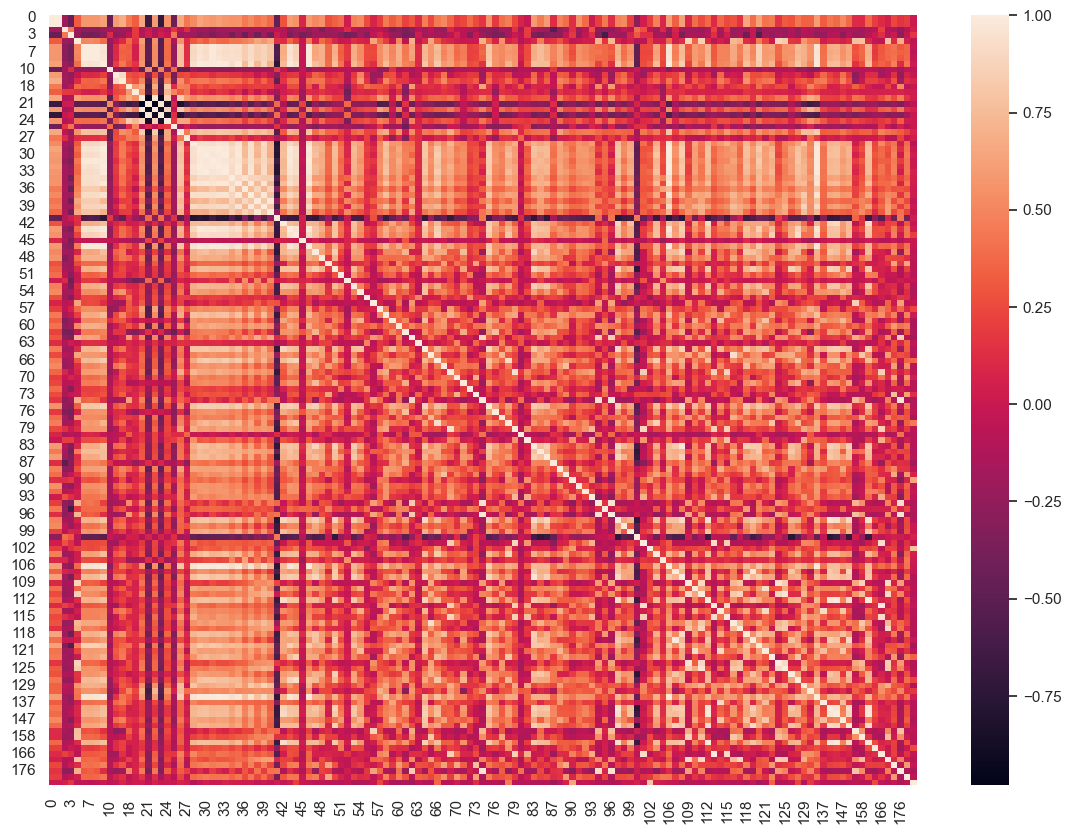

In [209]:
## correlation viz:
sns.heatmap(rdkit_var.corr())


In [210]:
## correlation removal (2 vars highly corr => to remove):
corr_matrix2 = rdkit_var.corr().abs() ## replace neg corr with their abs value
upper2 = corr_matrix2.where(np.triu(np.ones(corr_matrix2.shape), k = 1).astype(bool))

to_drop2 = [column for column in upper2.columns if any(upper2[column] > 0.9)] ## columns to remove due to high corr (say, 0.9)
rdkit_nocorr = rdkit_var.drop(columns = to_drop2)


<Axes: >

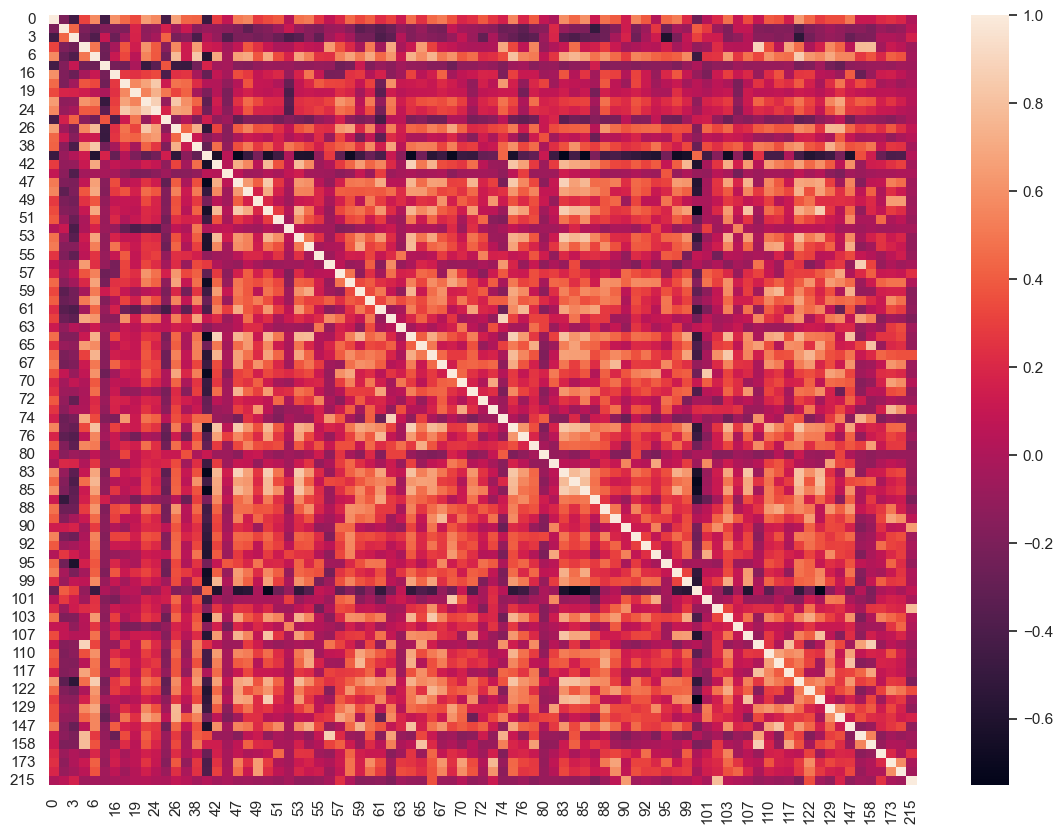

In [211]:
sns.heatmap(rdkit_nocorr.corr())


In [212]:
print(f"Dimension of RDKit database after cleaning and filtering: {rdkit_nocorr.shape}")


Dimension of RDKit database after cleaning and filtering: (67, 85)


#### II.5 - Save cleaned and filtered db in a .csv file:

In [213]:
## save cleaned & transformed db:
rdkit_nocorr.to_csv("../data/rdkit_clean.csv", index = False)
